# Part C: Classical Models and Evaluation
This notebook uses the breast-cancer data set solely as a technical classification benchmark. It is not a clinical or diagnostic system, and no result should be interpreted as medical advice or a real-world diagnosis.

In [43]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.metrics import RocCurveDisplay, precision_score, recall_score

project_root = Path.cwd().resolve()
if not (project_root / 'src').is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_processing import stratified_split_with_missing_validation_copy
from src.evaluation import ModelEvaluator

np.random.seed(42)

## Data Preparation
The data is loaded and split before any preprocessing, preserving a clean, stratified holdout set.

In [44]:
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test, X_train_with_missing = stratified_split_with_missing_validation_copy(X, y)

This copied training matrix exists solely to validate that an imputer step can handle missing values. It is not used in actual model training or evaluation; all four baseline models use the original clean split.

In [45]:
imputed_validation_data = SimpleImputer(strategy='median').fit_transform(X_train_with_missing)

This output verifies that approximately one percent of copied training entries were set missing and that the imputer produces a matrix without missing values.

In [46]:
print(f'Injected missing values: {np.isnan(X_train_with_missing).sum()}')
print(f'Missing values after imputation: {np.isnan(imputed_validation_data).sum()}')
print(f'Clean training data unchanged: {np.isnan(X_train).sum() == 0}')

Injected missing values: 127
Missing values after imputation: 0
Clean training data unchanged: True


The validation copy confirms missing values can be imputed, while the unchanged clean training matrix confirms this demonstration does not leak into the baseline modeling flow.

## Baseline Models
The four classical classifiers below are trained on the clean stratified training split. Predictions and positive-class probabilities are retained for shared evaluation.

In [47]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gaussian NB': GaussianNB(),
    'SVM': SVC(probability=True, random_state=42),
}
model_outputs = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    model_outputs[name] = {'predictions': model.predict(X_test), 'probabilities': model.predict_proba(X_test)[:, 1]}

## Evaluation
Each model is evaluated through the shared ModelEvaluator used elsewhere in the project. The table is sorted by F1 score, then business cost.

In [48]:
fn_cost = 5
fp_cost = 1
evaluator = ModelEvaluator(fn_weight=fn_cost, fp_weight=fp_cost)
evaluation_results = {}
for name, output in model_outputs.items():
    result = evaluator.evaluate(y_test, output['predictions'], output['probabilities'])
    matrix = np.array(result['confusion_matrix'])
    result['business_cost_from_matrix'] = fn_cost * matrix[1, 0] + fp_cost * matrix[0, 1]
    evaluation_results[name] = result
comparison_table = pd.DataFrame([{
    'model': name, 'accuracy': result['accuracy'], 'precision': result['precision'],
    'recall': result['recall'], 'f1': result['f1'], 'roc_auc': result['roc_auc'],
    'business_cost': result['business_cost_from_matrix']
} for name, result in evaluation_results.items()]).sort_values(['f1', 'business_cost'], ascending=[False, True]).reset_index(drop=True)
comparison_table

,model,accuracy,precision,recall,f1,roc_auc,business_cost
0,Random Forest,0.958042,0.956522,0.977778,0.967033,0.994864,14
1,Gaussian NB,0.937063,0.926316,0.977778,0.951351,0.989308,17
2,SVM,0.923077,0.907216,0.977778,0.941176,0.973585,19
3,Decision Tree,0.923077,0.954023,0.922222,0.937853,0.923375,39


The table makes the trade-off visible across accuracy, precision, recall, F1, ROC-AUC, and the configured cost of false negatives and false positives. Business cost comes directly from the confusion matrix returned by ModelEvaluator.

This combined plot shows the ROC curve for each classifier using its stored positive-class probability scores.

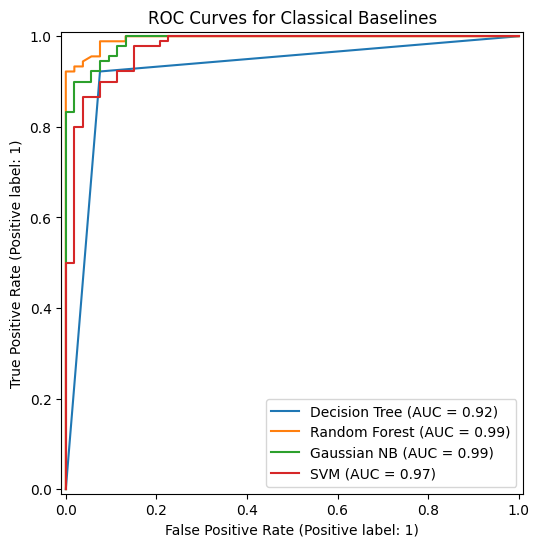

In [49]:
plt.figure(figsize=(8, 6))
for name, output in model_outputs.items():
    RocCurveDisplay.from_predictions(y_test, output['probabilities'], name=name, ax=plt.gca())
plt.title('ROC Curves for Classical Baselines')
plt.show()

ROC is a curve of true-positive rate against false-positive rate across thresholds. Curves nearer the upper-left generally indicate stronger ranking performance.

For SVM, ROC-AUC uses predict_proba positive-class scores, not predicted class labels. Labels collapse the confidence ranking to two values, so they discard the ordering information ROC-AUC requires.

## Business Scenario
The configured costs are named explicitly: a false negative costs five units and a false positive costs one unit. This cell extracts those error counts from each already-computed confusion matrix.

In [50]:
for name, result in evaluation_results.items():
    matrix = np.array(result['confusion_matrix'])
    false_positives = matrix[0, 1]
    false_negatives = matrix[1, 0]
    print(f"{name}: FN={false_negatives}, FP={false_positives}, cost={result['business_cost']:.1f}")

Decision Tree: FN=7, FP=4, cost=39.0
Random Forest: FN=2, FP=4, cost=14.0
Gaussian NB: FN=2, FP=7, cost=17.0
SVM: FN=2, FP=9, cost=19.0


The extracted false-positive and false-negative counts are taken from ModelEvaluator's confusion matrices; their weighted totals match the business-cost column in the comparison table.

This output selects a final model using both high F1 and low business cost, and compares it to the highest-accuracy model.

In [51]:
selected_model = comparison_table.iloc[0]
highest_accuracy_model = comparison_table.loc[comparison_table['accuracy'].idxmax()]
print(f"Selected model: {selected_model['model']}")
print(f"Selection basis: F1={selected_model['f1']:.3f}, business cost={selected_model['business_cost']:.1f}")
print(f"Highest-accuracy model: {highest_accuracy_model['model']}")
print(f"Highest accuracy differs from selection: {highest_accuracy_model['model'] != selected_model['model']}")

Selected model: Random Forest
Selection basis: F1=0.967, business cost=14.0
Highest-accuracy model: Random Forest
Highest accuracy differs from selection: False


The printed selection is the final baseline choice because it balances F1 with the asymmetric business cost, rather than relying on accuracy alone. If the highest-accuracy model is not selected, the difference is justified by the selected model's stronger F1-and-cost trade-off under the stated five-to-one false-negative cost.

## Required Discussion

### Why a Decision Tree may overfit
A decision tree can keep splitting until it learns highly specific patterns, including noise, in the training data. Deep or unconstrained trees therefore often have low training error but weaker performance on unseen examples.

### How Random Forest reduces variance
A random forest trains many trees on bootstrapped samples and random subsets of features. Averaging their predictions reduces the instability of an individual tree, lowering variance while preserving useful nonlinear structure.

### The main assumption made by Naive Bayes
Naive Bayes assumes that features are conditionally independent given the class label. This is often an approximation, but it can still yield useful and efficient baseline classifiers.

### Why feature scaling matters for SVM
SVM distances and kernel calculations can be dominated by features with larger numeric ranges, making feature scaling important. None of the four models here were scaled because this notebook intentionally presents baseline classical models; scaling is introduced properly in the Part D pipelines.

### Precision versus recall
Precision asks what fraction of predicted positives are actually positive. Recall asks what fraction of actual positives are found, so increasing sensitivity can lower precision when more false positives are admitted.

### When F1 is more useful than accuracy
F1 is useful when both precision and recall matter, especially with class imbalance where high accuracy can hide poor detection of a minority class. It combines the two rates with a harmonic mean that penalizes a severe weakness in either.

### ROC versus AUC
ROC is the curve plotting true-positive rate against false-positive rate across thresholds. AUC is the single scalar area under that curve, summarizing ranking discrimination over all thresholds.

### Threshold selection changes precision and recall
A lower probability threshold predicts more positives, which often increases recall while reducing precision. A higher threshold is more selective, commonly increasing precision while missing more true positives.

This threshold analysis recomputes labels from Random Forest probabilities at three thresholds and reports the resulting precision and recall.

In [52]:
threshold_rows = []
reference_probabilities = model_outputs['Random Forest']['probabilities']
for threshold in [0.3, 0.5, 0.7]:
    threshold_predictions = (reference_probabilities >= threshold).astype(int)
    threshold_rows.append({'threshold': threshold, 'precision': precision_score(y_test, threshold_predictions), 'recall': recall_score(y_test, threshold_predictions)})
pd.DataFrame(threshold_rows)

,threshold,precision,recall
0,0.3,0.936842,0.988889
1,0.5,0.956522,0.977778
2,0.7,0.988095,0.922222


The displayed rows concretely show the precision-recall trade-off: lowering the threshold admits more positive predictions and tends to recover more actual positives, while raising it demands stronger evidence.